# Hangman Solver — Test Demo & Accuracy on 200 Random Held-Out Words

**Author:** Siddhant Kumawat

This notebook loads the **pretrained BiLSTM weights** (`model_all`, `model_short`), the **train/test word splits**, rebuilds the exact fusion-based solver (BiLSTM probability + unigram/bigram statistical prior + information gain) from the main training notebook, and:

1. Runs a **single verbose demo game** so you can see the solver guess letter-by-letter.
2. Plays **200 randomly sampled games** from the held-out `test_words.txt` split (words the models never saw during training).
3. Reports **win rate (accuracy)**, average guesses on wins, average wrong tries used, and a win-rate-by-word-length breakdown.

### Expected inputs (attach as a Kaggle Dataset and update `INPUT_DIR` below if needed)
| File | Purpose |
|---|---|
| `train_words.txt` | Rebuilds `short_words` pool + unigram/bigram statistical priors (must match what the models were trained on) |
| `test_words.txt` | Held-out words to sample the 200 test games from |
| `model_all_weights.h5` (or similar) | Full-length BiLSTM model weights |
| `model_short_weights.h5` (or similar) | Short-word (≤16 chars) specialist BiLSTM model weights |

The notebook auto-searches `/kaggle/input/**` for these four files by name/substring, so it should work regardless of what you named the Kaggle Dataset.

## 0. Setup

In [15]:
import os
import re
import math
import string
import random
from collections import Counter, defaultdict
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)}")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass


TensorFlow version: 2.20.0
GPUs available: 2


## 1. Locate input files

Auto-searches every file under `/kaggle/input` (recursively) for the four files this notebook needs, matching on filename keywords so it doesn't matter exactly what the attached Kaggle Dataset(s) are called. If a file can't be found automatically, set its path manually in the `MANUAL_OVERRIDES` dict below.

In [16]:
MANUAL_OVERRIDES = {
    # "train_words": "/kaggle/input/your-dataset/train_words.txt",
    # "test_words":  "/kaggle/input/your-dataset/test_words.txt",
    # "model_all":   "/kaggle/input/your-dataset/model_all_weights.h5",
    # "model_short": "/kaggle/input/your-dataset/model_short_weights.h5",
}

SEARCH_ROOTS = ["/kaggle/input", "/kaggle/working"]

all_files = []
for root_dir in SEARCH_ROOTS:
    for dirname, _, filenames in os.walk(root_dir):
        for filename in filenames:
            all_files.append(os.path.join(dirname, filename))

print(f"Found {len(all_files)} files under {SEARCH_ROOTS}")


def find_file(keywords_any, keywords_all=None, ext=None):
    """Return the first file whose path contains all `keywords_all` (case-insensitive)
    and at least one of `keywords_any`, optionally filtered by extension."""
    keywords_all = keywords_all or []
    candidates = []
    for path in all_files:
        low = path.lower()
        if ext and not low.endswith(ext):
            continue
        if not all(k in low for k in keywords_all):
            continue
        if keywords_any and not any(k in low for k in keywords_any):
            continue
        candidates.append(path)
    return candidates[0] if candidates else None


TRAIN_WORDS_PATH = MANUAL_OVERRIDES.get("train_words") or find_file(
    keywords_any=["train_words", "train-words"], ext=".txt"
)
TEST_WORDS_PATH = MANUAL_OVERRIDES.get("test_words") or find_file(
    keywords_any=["test_words", "test-words"], ext=".txt"
)
MODEL_ALL_PATH = MANUAL_OVERRIDES.get("model_all") or find_file(
    keywords_any=["all"], keywords_all=["model"], ext=".h5"
)
MODEL_SHORT_PATH = MANUAL_OVERRIDES.get("model_short") or find_file(
    keywords_any=["short"], keywords_all=["model"], ext=".h5"
)

print("TRAIN_WORDS_PATH :", TRAIN_WORDS_PATH)
print("TEST_WORDS_PATH  :", TEST_WORDS_PATH)
print("MODEL_ALL_PATH   :", MODEL_ALL_PATH)
print("MODEL_SHORT_PATH :", MODEL_SHORT_PATH)

for name, path in [("train_words", TRAIN_WORDS_PATH), ("test_words", TEST_WORDS_PATH),
                    ("model_all", MODEL_ALL_PATH), ("model_short", MODEL_SHORT_PATH)]:
    if path is None:
        raise FileNotFoundError(
            f"Could not auto-locate '{name}'. Add its path to MANUAL_OVERRIDES above and re-run this cell."
        )


Found 5 files under ['/kaggle/input', '/kaggle/working']
TRAIN_WORDS_PATH : /kaggle/input/datasets/siddhant-kumawat/alphaaaa/train_words.txt
TEST_WORDS_PATH  : /kaggle/input/datasets/siddhant-kumawat/alphaaaa/test_words.txt
MODEL_ALL_PATH   : /kaggle/input/datasets/siddhant-kumawat/alphaaaa/model_all.weights (2).h5
MODEL_SHORT_PATH : /kaggle/input/datasets/siddhant-kumawat/alphaaaa/model_short.weights (1).h5


## 2. Load & clean the word lists

Same cleaning rule used to train the models: alphabetic words between 3 and 30 characters, with more than one distinct letter. `train_words.txt` rebuilds the `short_words` pool (≤16 chars) used for candidate filtering + statistical priors — this **must** be the same train split the models were trained on, otherwise the priors/candidate lists won't match what the models learned.

In [17]:
def clean_word_list(word_list, min_length=3, max_length=30):
    """Filter out unwanted words (too short/long, non-alphabetic, or single-letter-repeat)."""
    cleaned_words = []
    for word in word_list:
        if (
            min_length <= len(word) <= max_length
            and word.isalpha()
            and len(set(word)) > 1
        ):
            cleaned_words.append(word)
    return cleaned_words


with open(TRAIN_WORDS_PATH, "r") as f:
    train_raw = [line.strip() for line in f.read().splitlines() if line.strip()]
clean_words = clean_word_list(train_raw)
short_words = [w for w in clean_words if 0 < len(w) <= 16]

with open(TEST_WORDS_PATH, "r") as f:
    test_raw = [line.strip() for line in f.read().splitlines() if line.strip()]
test_words = clean_word_list(test_raw)

print(f"Train (clean)      : {len(clean_words):,} words")
print(f"Train short (<=16) : {len(short_words):,} words")
print(f"Test (clean)       : {len(test_words):,} words")

# sanity check: confirm test words are genuinely held out from train
overlap = set(test_words) & set(clean_words)
print(f"Overlap between train and test words: {len(overlap)} "
      f"({'OK -- no leakage' if len(overlap) == 0 else 'WARNING -- leakage detected'})")


Train (clean)      : 221,334 words
Train short (<=16) : 217,953 words
Test (clean)       : 5,675 words
Overlap between train and test words: 0 (OK -- no leakage)


## 3. Vocabulary & encoding

Identical to the training notebook: index `0` is the padding token (for `Embedding(..., mask_zero=True)`), letters `a`-`z` map to `1`-`26`, and `_` (the blank/mask token) maps to `27`.

In [18]:
CHAR_TO_IDX = {chr(i + 97): i + 1 for i in range(26)}   # 'a'-'z' -> 1-26
CHAR_TO_IDX['_'] = 27                                    # mask/blank token
PAD_IDX, MASK_IDX = 0, 27
VOCAB_SIZE = 28                                          # pad + 26 letters + blank
MAX_LEN = 30

IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}


def encode_word(word: str, max_len: int = MAX_LEN) -> List[int]:
    """Right-pad / truncate a (possibly masked) word to `max_len`."""
    enc = [CHAR_TO_IDX.get(c, PAD_IDX) for c in word.lower()]
    enc = (enc + [PAD_IDX] * max_len)[:max_len]
    return enc


## 4. Model architecture — BiLSTM

Must exactly match the architecture used to produce the saved weight files (`hidden_dim=256`, `emb_dim=64`, `num_layers=2`), otherwise `load_weights` will raise a shape/name-mismatch error.

**Two pitfalls this cell works around:**

1. **File-extension format detection.** The original notebook saved weights with `model.save_weights(".../model_all.weights.h5")` — Keras's *new native weights-only format*, which is only auto-detected when the path ends with the exact literal suffix `.weights.h5`. After downloading and re-attaching the file as a Kaggle Dataset input, it's commonly renamed (e.g. to `model_all_weights__2_.h5`), which no longer ends in `.weights.h5`. Keras then silently assumes the *old legacy* HDF5 format instead, and the legacy loader can't parse the new-format bytes — producing `ValueError: Layer count mismatch ... found 0 saved layers`, regardless of the architecture being correct. **Fix:** copy each input file to a working path that ends in exactly `.weights.h5` before loading.
2. **Layer-name alignment.** In the original training notebook, a throwaway `test_model = build_model(hidden_dim=256)` was built *before* `model_all` and `model_short`. Keras auto-names layers with a counter that persists for the life of the Python session, so that throwaway model quietly consumed the first name slot — the saved weight files internally reference names like `hangman_bi_lstm_1` / `embedding_1` (for `model_all`) and `hangman_bi_lstm_2` / `embedding_2` (for `model_short`), not the plain names a freshly built model gets in a brand-new session. **Fix:** reproduce that exact build order (`_warmup_model` first, then `model_all`, then `model_short`) so the auto-generated names line up with what's stored in the `.h5` files.

In [19]:
class HangmanBiLSTM(keras.Model):
    def __init__(self, vocab_size=VOCAB_SIZE, emb_dim=64, hidden_dim=128, num_layers=2, **kwargs):
        super().__init__(**kwargs)
        self.embedding = layers.Embedding(vocab_size, emb_dim, mask_zero=True)
        self.lstm_layers = [
            layers.Bidirectional(layers.LSTM(hidden_dim, return_sequences=True))
            for _ in range(num_layers)
        ]
        self.classifier = layers.Dense(26)

    def call(self, x, lengths, training=False):
        mask = self.embedding.compute_mask(x)
        h = self.embedding(x)
        for lstm in self.lstm_layers:
            h = lstm(h, mask=mask, training=training)

        # gather the hidden state at each sample's true last valid timestep
        batch_idx = tf.range(tf.shape(h)[0])
        last_idx = tf.cast(lengths, tf.int32) - 1
        last_idx = tf.clip_by_value(last_idx, 0, tf.shape(h)[1] - 1)
        gather_idx = tf.stack([batch_idx, last_idx], axis=1)
        final = tf.gather_nd(h, gather_idx)

        return self.classifier(final)


def build_model(**kwargs):
    """kwargs forwarded to HangmanBiLSTM, e.g. build_model(hidden_dim=256)."""
    model = HangmanBiLSTM(**kwargs)
    # build weights with a dummy forward pass
    dummy_x = tf.zeros((1, MAX_LEN), dtype=tf.int32)
    dummy_len = tf.constant([1], dtype=tf.int32)
    _ = model(dummy_x, dummy_len, training=False)
    return model


HIDDEN_DIM = 256   # both model_all and model_short were trained with 256 hidden units

# ---- pitfall #1 fix: copy to a path ending in the exact literal suffix
# ---- ".weights.h5" so Keras auto-detects the new native weights format
# ---- instead of misreading these as legacy-format files ----
import shutil

os.makedirs("/kaggle/working", exist_ok=True)


def ensure_weights_h5_suffix(src_path, canonical_name):
    dst_path = os.path.join("/kaggle/working", canonical_name)
    if not dst_path.endswith(".weights.h5"):
        raise ValueError(f"canonical_name must end with '.weights.h5', got {canonical_name!r}")
    if os.path.abspath(src_path) != os.path.abspath(dst_path):
        shutil.copyfile(src_path, dst_path)
    return dst_path


MODEL_ALL_WEIGHTS_H5 = ensure_weights_h5_suffix(MODEL_ALL_PATH, "model_all.weights.h5")
MODEL_SHORT_WEIGHTS_H5 = ensure_weights_h5_suffix(MODEL_SHORT_PATH, "model_short.weights.h5")
print(f"Normalized model_all weights path   -> {MODEL_ALL_WEIGHTS_H5}")
print(f"Normalized model_short weights path -> {MODEL_SHORT_WEIGHTS_H5}")

# ---- pitfall #2 fix: reproduce the original notebook's build order so
# ---- auto-generated layer names match what's stored inside the .h5 files ----
_warmup_model = build_model(hidden_dim=HIDDEN_DIM)   # mirrors the original `test_model` -- consumes the first name slot, never used again

model_all = build_model(hidden_dim=HIDDEN_DIM)
model_all.load_weights(MODEL_ALL_WEIGHTS_H5)
print(f"Loaded pretrained weights from {MODEL_ALL_WEIGHTS_H5}")

model_short = build_model(hidden_dim=HIDDEN_DIM)
model_short.load_weights(MODEL_SHORT_WEIGHTS_H5)
print(f"Loaded pretrained weights from {MODEL_SHORT_WEIGHTS_H5}")

del _warmup_model


Normalized model_all weights path   -> /kaggle/working/model_all.weights.h5
Normalized model_short weights path -> /kaggle/working/model_short.weights.h5
Loaded pretrained weights from /kaggle/working/model_all.weights.h5
Loaded pretrained weights from /kaggle/working/model_short.weights.h5


## 5. Statistical language priors & information gain

Framework-independent (pure Python) backstop signal — unigram/bigram letter frequency plus information gain over the candidate word set — fused with the BiLSTM's predictions. Computed from `short_words` (the **train** split), matching how the original solver was built.

In [20]:
uni_cnt = Counter("".join(short_words))
total_u = sum(uni_cnt.values())
P_uni = {ch: uni_cnt[ch] / total_u for ch in string.ascii_lowercase}

bi_cnt = Counter((a, b) for w in short_words for a, b in zip(w, w[1:]))
total_b = sum(bi_cnt.values())
P_bi = {bg: bi_cnt[bg] / total_b for bg in bi_cnt}


def compute_conditional_prior(candidates):
    cnt = Counter("".join(candidates))
    tot = sum(cnt.values())
    if tot == 0:
        return {ch: 0.0 for ch in string.ascii_lowercase}
    return {ch: cnt[ch] / tot for ch in string.ascii_lowercase}


def compute_info_gain(candidates):
    C = len(candidates)
    if C == 0:
        return {ch: 0.0 for ch in string.ascii_lowercase}
    mem = defaultdict(int)
    for w in candidates:
        for ch in set(w):
            mem[ch] += 1
    ig = {}
    for ch in string.ascii_lowercase:
        yes = mem[ch]
        no = C - yes
        py, pn = yes / C, no / C
        val = 0.0
        if py > 0:
            val += py * (math.log2(C) - math.log2(yes))
        if pn > 0 and no > 0:
            val += pn * (math.log2(C) - math.log2(no))
        ig[ch] = val
    return ig


print("Priors & info-gain helpers ready.")


Priors & info-gain helpers ready.


## 6. Solver — letter-guessing + local game loop

Same fused BiLSTM + statistical-prior + information-gain logic as `MyHangmanSolver.guess()`, refactored to run fully offline (no Trexquant API calls) so it can be batch-tested here.

In [21]:
def local_guess_letter(pattern, guessed_letters, model_all, model_short, short_words,
                        P_uni, P_bi, alpha=0.8, beta=0.0, gamma=0.2,
                        w1=0.3, w2=0.2, w3=0.5):
    """Choose the next letter to guess given the current masked pattern
    (e.g. '_pp_e') and the set of letters already guessed."""
    pattern = pattern.lower()
    L = len(pattern)

    VOWELS = sorted(list("eaiou"), key=lambda c: -P_uni[c])
    CONSONANTS = [c for c in string.ascii_lowercase if c not in VOWELS]
    CONSONANTS.sort(key=lambda c: -P_uni[c])

    # tiny-word fallback
    if L <= 3:
        for ch in VOWELS:
            if ch not in guessed_letters:
                return ch
        for ch in CONSONANTS:
            if ch not in guessed_letters:
                return ch
        return "e"

    # candidate words consistent with the current pattern
    cands = [
        w for w in short_words
        if len(w) == L
        and all(pc == "_" or pc == wc for pc, wc in zip(pattern, w))
    ]

    net = model_all if L > 16 else model_short
    x_in = tf.constant([encode_word(pattern, MAX_LEN)], dtype=tf.int32)
    l_in = tf.constant([L], dtype=tf.int32)
    logits = net(x_in, l_in, training=False)
    probs = tf.nn.softmax(logits, axis=1).numpy()[0]
    model_p = {string.ascii_lowercase[i]: probs[i] for i in range(26)}

    stat_scores = {}
    if L <= 16:
        cp = compute_conditional_prior(cands)
        for ch in string.ascii_lowercase:
            if ch in guessed_letters:
                continue
            s1 = P_uni.get(ch, 0.0)
            bs = []
            for i, pc in enumerate(pattern):
                if pc == "_":
                    lp = pattern[i - 1] if i > 0 else None
                    rp = pattern[i + 1] if i < L - 1 else None
                    if lp and lp != "_":
                        bs.append(P_bi.get((lp, ch), 0.0))
                    if rp and rp != "_":
                        bs.append(P_bi.get((ch, rp), 0.0))
            s2 = sum(bs) / len(bs) if bs else 0.0
            s3 = cp.get(ch, 0.0)
            stat_scores[ch] = (
                w1 * math.log(s1 + 1e-12)
                + w2 * math.log(s2 + 1e-12)
                + w3 * math.log(s3 + 1e-12)
            )

    ig_scores = compute_info_gain(cands) if L <= 16 else {}

    best_score, best_ch = -1e9, None
    for ch in string.ascii_lowercase:
        if ch in guessed_letters:
            continue
        m = math.log(model_p.get(ch, 1e-12))
        st = stat_scores.get(ch, 0.0)
        ig = ig_scores.get(ch, 0.0)
        score = alpha * m + (1 - alpha) * (beta * st + gamma * ig)
        if score > best_score:
            best_score, best_ch = score, ch

    return best_ch


def play_local_game(secret_word, max_tries=6, verbose=True, **guess_kwargs):
    """Play one offline Hangman game against the trained models.
    Standard rules: `max_tries` wrong guesses allowed (default 6, same as the live server)."""
    secret_word = secret_word.lower()
    guessed_letters = set()
    revealed = ['_'] * len(secret_word)
    tries_remaining = max_tries
    n_guesses = 0

    while True:
        current_pattern = ''.join(revealed)

        # ----- win condition -----
        if '_' not in current_pattern:
            if verbose:
                print(f"WON  -> '{secret_word}'  (guesses used: {n_guesses}, tries left: {tries_remaining})")
            return {
                'word': secret_word, 'length': len(secret_word), 'result': 'WIN',
                'tries_used': max_tries - tries_remaining, 'n_guesses': n_guesses,
                'guessed_letters': ''.join(sorted(guessed_letters)),
            }

        # ----- loss condition -----
        if tries_remaining <= 0:
            if verbose:
                print(f"LOST -> '{secret_word}'  (revealed: {current_pattern})")
            return {
                'word': secret_word, 'length': len(secret_word), 'result': 'LOSS',
                'tries_used': max_tries, 'n_guesses': n_guesses,
                'guessed_letters': ''.join(sorted(guessed_letters)),
            }

        # ----- pick next letter -----
        guess_letter = local_guess_letter(current_pattern, guessed_letters, **guess_kwargs)
        guessed_letters.add(guess_letter)
        n_guesses += 1

        # ----- manual tries bookkeeping -----
        if guess_letter in secret_word:
            for i, ch in enumerate(secret_word):
                if ch == guess_letter:
                    revealed[i] = ch
            if verbose:
                print(f"  guess '{guess_letter}' -> HIT   | {''.join(revealed)}")
        else:
            tries_remaining -= 1
            if verbose:
                print(f"  guess '{guess_letter}' -> MISS  | tries left: {tries_remaining}")


## 7. Single-game demo (verbose)

Picks one random word from the held-out `test_words.txt` and plays it out letter-by-letter so you can see the solver working.

In [22]:
random.seed(SEED)
demo_word = random.choice(test_words)
print(f"Demo game -- secret word: '{demo_word}'\n")

_ = play_local_game(
    demo_word, max_tries=6, verbose=True,
    model_all=model_all, model_short=model_short, short_words=short_words,
    P_uni=P_uni, P_bi=P_bi,
)


Demo game -- secret word: 'ultraprotestantism'

  guess 'e' -> HIT   | _________e________
  guess 'i' -> HIT   | _________e_____i__
  guess 'n' -> HIT   | _________e___n_i__
  guess 't' -> HIT   | __t_____te_t_nti__
  guess 'o' -> HIT   | __t____ote_t_nti__
  guess 'a' -> HIT   | __t_a__ote_tanti__
  guess 'r' -> HIT   | __tra_rote_tanti__
  guess 'c' -> MISS  | tries left: 5
  guess 's' -> HIT   | __tra_rotestantis_
  guess 'm' -> HIT   | __tra_rotestantism
  guess 'p' -> HIT   | __traprotestantism
  guess 'u' -> HIT   | u_traprotestantism
  guess 'l' -> HIT   | ultraprotestantism
WON  -> 'ultraprotestantism'  (guesses used: 13, tries left: 5)


## 8. Batch test — 200 random held-out words

Samples 200 words (without replacement, seeded for reproducibility) from `test_words.txt` and plays each one out to completion.

In [27]:
N_TEST_GAMES = 5000
TEST_SEED = 123

rng = random.Random(TEST_SEED)
n_sample = min(N_TEST_GAMES, len(test_words))
test_sample = rng.sample(test_words, n_sample)
print(f"Sampling {len(test_sample)} words from the {len(test_words):,}-word held-out test set.")

results = []
for i, w in enumerate(test_sample, 1):
    res = play_local_game(
        w, max_tries=6, verbose=False,
        model_all=model_all, model_short=model_short, short_words=short_words,
        P_uni=P_uni, P_bi=P_bi,
    )
    results.append(res)
    if i % 50 == 0:
        print(f"  ...played {i}/{len(test_sample)} games")

results_df = pd.DataFrame(results)
results_df.head(10)


Sampling 5000 words from the 5,675-word held-out test set.
  ...played 50/5000 games
  ...played 100/5000 games
  ...played 150/5000 games
  ...played 200/5000 games
  ...played 250/5000 games
  ...played 300/5000 games
  ...played 350/5000 games
  ...played 400/5000 games
  ...played 450/5000 games
  ...played 500/5000 games
  ...played 550/5000 games
  ...played 600/5000 games
  ...played 650/5000 games
  ...played 700/5000 games
  ...played 750/5000 games
  ...played 800/5000 games
  ...played 850/5000 games
  ...played 900/5000 games
  ...played 950/5000 games
  ...played 1000/5000 games
  ...played 1050/5000 games
  ...played 1100/5000 games
  ...played 1150/5000 games
  ...played 1200/5000 games
  ...played 1250/5000 games
  ...played 1300/5000 games
  ...played 1350/5000 games
  ...played 1400/5000 games
  ...played 1450/5000 games
  ...played 1500/5000 games
  ...played 1550/5000 games
  ...played 1600/5000 games
  ...played 1650/5000 games
  ...played 1700/5000 games
  ...play

,word,length,result,tries_used,n_guesses,guessed_letters
0,lunges,6,LOSS,6,10,adeilorstu
1,granuloadipose,14,WIN,5,17,abcdegilmnoprstuv
2,twiceviolated,13,WIN,4,14,acdefilnorstvw
3,prepollices,11,LOSS,6,12,adeiklprstuz
4,blepharospath,13,WIN,3,13,abcehilnoprst
5,phaye,5,LOSS,6,8,acelnrst
6,sequestratrix,13,LOSS,6,12,acdeilmnprst
7,thionitrite,11,WIN,1,8,aehinort
8,paulins,7,WIN,4,11,abceilnprsu
9,pterna,6,WIN,2,8,aeinprst


## 9. Accuracy / win-rate report

In [28]:
win_rate = (results_df['result'] == 'WIN').mean()
avg_guesses_win = results_df.loc[results_df['result'] == 'WIN', 'n_guesses'].mean()
avg_tries_used = results_df['tries_used'].mean()

print(f"Games played         : {len(results_df)}")
print(f"Wins                 : {(results_df['result']=='WIN').sum()}")
print(f"Losses               : {(results_df['result']=='LOSS').sum()}")
print(f"Win rate (accuracy)  : {win_rate:.2%}")
print(f"Avg guesses on wins  : {avg_guesses_win:.2f}")
print(f"Avg wrong tries used : {avg_tries_used:.2f} / 6")


Games played         : 5000
Wins                 : 2810
Losses               : 2190
Win rate (accuracy)  : 56.20%
Avg guesses on wins  : 11.00
Avg wrong tries used : 4.28 / 6


## 10. Win rate by word length

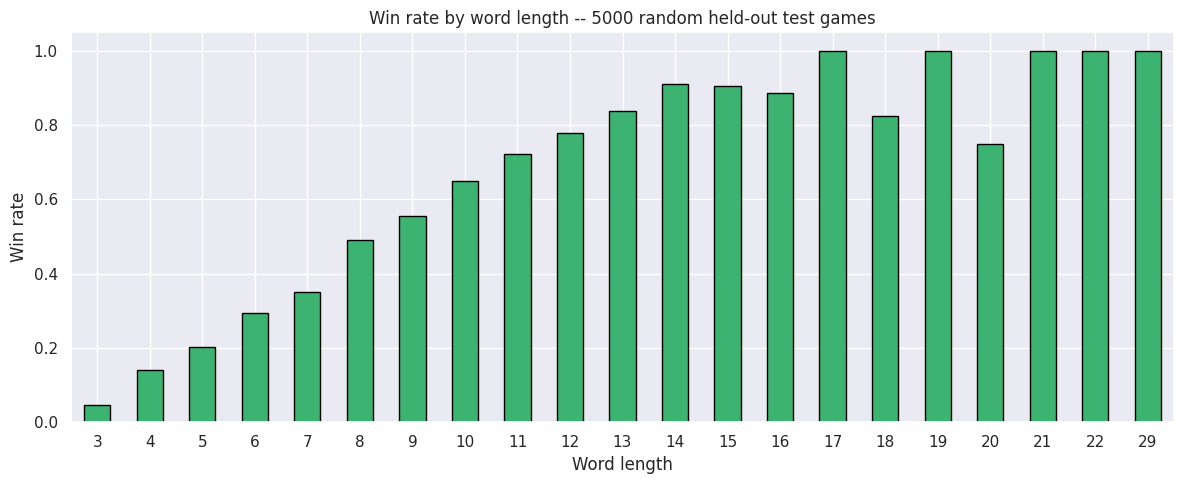

In [29]:
by_len = results_df.groupby('length')['result'].apply(lambda s: (s == 'WIN').mean())

plt.figure(figsize=(12, 5))
by_len.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title(f'Win rate by word length -- {len(results_df)} random held-out test games')
plt.xlabel('Word length'); plt.ylabel('Win rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11. Save results

In [32]:
os.makedirs("/kaggle/working", exist_ok=True)
out_path = "/kaggle/working/test_results_200.csv"
results_df.to_csv(out_path, index=False)
print(f"Saved per-game results -> {out_path}")

summary = {
    "n_games": len(results_df),
    "wins": int((results_df['result'] == 'WIN').sum()),
    "losses": int((results_df['result'] == 'LOSS').sum()),
    "win_rate": float(win_rate),
    "avg_guesses_on_wins": float(avg_guesses_win),
    "avg_tries_used": float(avg_tries_used),
}
print(summary)


Saved per-game results -> /kaggle/working/test_results_200.csv
{'n_games': 5000, 'wins': 2810, 'losses': 2190, 'win_rate': 0.562, 'avg_guesses_on_wins': 11.002491103202846, 'avg_tries_used': 4.281}
